In [50]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [51]:
permits = pd.read_csv("data/permits/processed/permits.csv")
permits_old = pd.read_csv(
    "./data/permits/permits_old/Iowa_Animal_Feeding_Operations.csv"
)
permits_old.columns = permits_old.columns.str.lower()

In [75]:
# check that both have unique ids
assert len(permits["facilityid"].unique()) == len(permits)
assert len(permits_old["progid"].unique()) == len(permits_old)

In [76]:
# merge the two datasets
permits_old.head()

,x,y,objectid,maplabelna,legendtype,publicview,uniqueid,locid,stfacid,progid,facname,locaddress,cityname,state,loczip,countyname,fo,locsupplem,opstatus,operattype,swine,cattledair,cattlebeef,chickens,turkeys,horses,sheeplgoat,other,animalunit,conspermit,npdespermit,mmp,pindexmmp,nmp,basininspection,townshipna,tier,range,rangedir,sectn,latitude,longitude,x_coord,y_coord,accuracy,colmthtxt,refpnttxt,verifytxt,collectby,coldate,loccomment,congress,sthouse,stsenate,huc,hyperlink
0,366233.0,4788728.0,549,Daybreak Foods,7,1,1,20000121855,310201586,60670,Daybreak Foods,4768 280TH ST,Graettinger,IA,50536,Palo Alto,3.0,NaN,Active,Confinement,NaN,NaN,NaN,16999.0,NaN,NaN,NaN,0,16999.62,Y,N,Y,N,N,No,VERNON,NaN,NaN,NaN,NaN,43.24134,-94.64607,366357,4788931,15.0,GPS CODE (PSEUDO RANGE) STANDARD POSITION (SA ...,PLANT ENTRANCE (GENERAL),NaN,cwolter,2006/05/05 10:17:27+00,NaN,04,7.0,4.0,071000020205,https://programs.iowadnr.gov/animalfeedingoper...
1,373347.0,4617113.0,2790,Guthrie Center Egg Farm,7,1,2,20000121887,310201777,61163,Guthrie Center Egg Farm - Laop,2143 215TH ROAD,Guthrie Center,IA,50115-8542,Guthrie,4.0,NaN,Active,Confinement,NaN,NaN,NaN,13893.0,NaN,NaN,NaN,0,13893.00,Y,Y,Y,N,N,Yes,Seely,80.0,32,W,36.0,41.69573,-94.52205,373347,4617113,20.0,INTERPOLATION-PHOTO,PLANT ENTRANCE (GENERAL),POINT IN POLYGON (COUNTY),mark.las,2011/07/27 15:20:42+00,NaN,04,58.0,29.0,071000070404,https://programs.iowadnr.gov/animalfeedingoper...
2,327318.0,4579001.0,368,Wallace Foundation Learning Center,7,0,3,20000123245,310336875,65655,Wallace Foundation Learning Center,LANSING RD,Atlantic,IA,50022,Pottawattamie,4.0,NaN,Inactive,Confinement,150.0,NaN,NaN,NaN,NaN,NaN,NaN,0,150.00,N,N,NaN,NaN,NaN,No,WASHINGTON,NaN,NaN,NaN,NaN,41.34591,-95.06566,327181,4579216,15.0,GPS CODE (PSEUDO RANGE) STANDARD POSITION (SA ...,CENTER OF FACILITY,NaN,zachery.,2016/11/22 00:00:00+00,moved to middle of building,04,57.0,29.0,102400030502,https://programs.iowadnr.gov/animalfeedingoper...
3,301720.0,4802451.0,2785,"Sunrise Farms, Inc",7,0,4,20000124908,310351516,61210,"Sunrise Farms, Inc",2060 WHITE AVE,Harris,IA,51345,Osceola,3.0,NaN,Active,Confinement,NaN,NaN,NaN,80000.0,NaN,NaN,NaN,0,80000.00,Y,Y,Y,N,N,Yes,ALLISON,NaN,NaN,NaN,NaN,43.34870,-95.44726,301656,4802447,20.0,INTERPOLATION-PHOTO,PLANT ENTRANCE (GENERAL),NaN,zachery.,2017/05/18 00:00:00+00,NaN,04,5.0,3.0,102300030504,https://programs.iowadnr.gov/animalfeedingoper...
4,325745.0,4743437.0,1750,Rembrandt Enterprises Inc (rembrandt),7,1,5,20000128243,310343134,61129,Rembrandt Enterprises Inc (rembrandt),1419 480TH ST,Rembrandt,IA,50576,Buena Vista,3.0,NaN,Active,Confinement,NaN,NaN,NaN,65019.0,NaN,NaN,NaN,0,65019.20,Y,Y,Y,N,N,No,LEE,NaN,NaN,NaN,NaN,42.82366,-95.13176,325745,4743437,15.0,GPS CODE (PSEUDO RANGE) STANDARD POSITION (SA ...,PLANT ENTRANCE (GENERAL),NaN,MMoeller,2006/05/12 00:00:00+00,First point clicked in WUSE map applet,04,52.0,26.0,071000060302,https://programs.iowadnr.gov/animalfeedingoper...


In [77]:
permits.head()

,Unnamed: 0,facilityid,facilityna,address,city,state,zip,latitude,longitude,county,fieldoffic,animal_units,opeartiont,plantype,last_plan,first_plan,cattle_bee,cattle_b_1,immature_d,mature_dai,cattle_dai,cattle_vea,chicken_la,chicken_pu,cow_calf,ducks,fish___25,fish_____2,goats,horses,sheep_and,swine_gest,swine_gilt,swine_grow,swine_nurs,swine_sow,swine_wean,turkey_fin,turkey_pou,collection,collectedb,collecti_1,locationco,geometry,swine_animal_units
0,0,56216,Mark Steinke Farm,12450 130th Street,Gibson,IA,50104,41.47140,-92.37595,Keokuk,6,400,Open Feedlot,NMP,2022-02-23,2007-08-24,0,400,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,INTERPOLATION-PHOTO,zachery.,2016-11-23,moved to middle of feedlot,POINT (552107.9792554432 4591277.013664194),0
1,1,56217,Gregory Feedlots Inc.,66592 US Highway 275,Tabor,IA,0,40.92033,-95.67444,Mills,4,2000,Open Feedlot,NMP,2019-07-16,2007-09-05,0,2000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,INTERPOLATION-PHOTO,zachery.,2017-05-02,NaN,POINT (274793.12042219035 4533357.125325268),0
2,2,56219,Beason Cattle,2285 300th Street,Bedford,IA,50833,40.61342,-94.69540,Taylor,4,350,Confinement,Pindex MMP -original,2017-08-02,2012-07-31,350,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,INTERPOLATION-PHOTO,cwolter,2008-05-16,NaN,POINT (356581.2049050957 4497225.933288046),0
3,3,56222,Hoogland Feedlot,2998 480th St,Maurice,IA,51036,42.95344,-96.19602,Sioux,3,3440,Confinement/Open Feedlot,200A,2022-06-29,2006-06-20,0,3440,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,INTERPOLATION-PHOTO,ckahle,2007-01-09,"legal, tiger, cir",POINT (239291.2184951422 4760601.785125998),0
4,4,56223,Tripple D Feeders,65708 Jackson Road,Atlantic,IA,50022,41.37795,-94.93266,Cass,4,400,Open Feedlot,NaN,NaN,NaN,0,400,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,INTERPOLATION-PHOTO,cwolter,2008-05-16,NaN,POINT (338388.43155864475 4582516.583139044),0


In [78]:
permits_old.head()

,x,y,objectid,maplabelna,legendtype,publicview,uniqueid,locid,stfacid,progid,facname,locaddress,cityname,state,loczip,countyname,fo,locsupplem,opstatus,operattype,swine,cattledair,cattlebeef,chickens,turkeys,horses,sheeplgoat,other,animalunit,conspermit,npdespermit,mmp,pindexmmp,nmp,basininspection,townshipna,tier,range,rangedir,sectn,latitude,longitude,x_coord,y_coord,accuracy,colmthtxt,refpnttxt,verifytxt,collectby,coldate,loccomment,congress,sthouse,stsenate,huc,hyperlink
0,366233.0,4788728.0,549,Daybreak Foods,7,1,1,20000121855,310201586,60670,Daybreak Foods,4768 280TH ST,Graettinger,IA,50536,Palo Alto,3.0,NaN,Active,Confinement,NaN,NaN,NaN,16999.0,NaN,NaN,NaN,0,16999.62,Y,N,Y,N,N,No,VERNON,NaN,NaN,NaN,NaN,43.24134,-94.64607,366357,4788931,15.0,GPS CODE (PSEUDO RANGE) STANDARD POSITION (SA ...,PLANT ENTRANCE (GENERAL),NaN,cwolter,2006/05/05 10:17:27+00,NaN,04,7.0,4.0,071000020205,https://programs.iowadnr.gov/animalfeedingoper...
1,373347.0,4617113.0,2790,Guthrie Center Egg Farm,7,1,2,20000121887,310201777,61163,Guthrie Center Egg Farm - Laop,2143 215TH ROAD,Guthrie Center,IA,50115-8542,Guthrie,4.0,NaN,Active,Confinement,NaN,NaN,NaN,13893.0,NaN,NaN,NaN,0,13893.00,Y,Y,Y,N,N,Yes,Seely,80.0,32,W,36.0,41.69573,-94.52205,373347,4617113,20.0,INTERPOLATION-PHOTO,PLANT ENTRANCE (GENERAL),POINT IN POLYGON (COUNTY),mark.las,2011/07/27 15:20:42+00,NaN,04,58.0,29.0,071000070404,https://programs.iowadnr.gov/animalfeedingoper...
2,327318.0,4579001.0,368,Wallace Foundation Learning Center,7,0,3,20000123245,310336875,65655,Wallace Foundation Learning Center,LANSING RD,Atlantic,IA,50022,Pottawattamie,4.0,NaN,Inactive,Confinement,150.0,NaN,NaN,NaN,NaN,NaN,NaN,0,150.00,N,N,NaN,NaN,NaN,No,WASHINGTON,NaN,NaN,NaN,NaN,41.34591,-95.06566,327181,4579216,15.0,GPS CODE (PSEUDO RANGE) STANDARD POSITION (SA ...,CENTER OF FACILITY,NaN,zachery.,2016/11/22 00:00:00+00,moved to middle of building,04,57.0,29.0,102400030502,https://programs.iowadnr.gov/animalfeedingoper...
3,301720.0,4802451.0,2785,"Sunrise Farms, Inc",7,0,4,20000124908,310351516,61210,"Sunrise Farms, Inc",2060 WHITE AVE,Harris,IA,51345,Osceola,3.0,NaN,Active,Confinement,NaN,NaN,NaN,80000.0,NaN,NaN,NaN,0,80000.00,Y,Y,Y,N,N,Yes,ALLISON,NaN,NaN,NaN,NaN,43.34870,-95.44726,301656,4802447,20.0,INTERPOLATION-PHOTO,PLANT ENTRANCE (GENERAL),NaN,zachery.,2017/05/18 00:00:00+00,NaN,04,5.0,3.0,102300030504,https://programs.iowadnr.gov/animalfeedingoper...
4,325745.0,4743437.0,1750,Rembrandt Enterprises Inc (rembrandt),7,1,5,20000128243,310343134,61129,Rembrandt Enterprises Inc (rembrandt),1419 480TH ST,Rembrandt,IA,50576,Buena Vista,3.0,NaN,Active,Confinement,NaN,NaN,NaN,65019.0,NaN,NaN,NaN,0,65019.20,Y,Y,Y,N,N,No,LEE,NaN,NaN,NaN,NaN,42.82366,-95.13176,325745,4743437,15.0,GPS CODE (PSEUDO RANGE) STANDARD POSITION (SA ...,PLANT ENTRANCE (GENERAL),NaN,MMoeller,2006/05/12 00:00:00+00,First point clicked in WUSE map applet,04,52.0,26.0,071000060302,https://programs.iowadnr.gov/animalfeedingoper...


In [111]:
df_inner = pd.merge(
    permits, permits_old, left_on="facilityid", right_on="progid", how="inner"
)

In [80]:
# compare shapes
print("There are", permits.shape[0], "permits in the new dataset")
print("There are", permits_old.shape[0], "permits in the old dataset")
print("There are", df_inner.shape[0], "permits in the merged dataset")

There are 10581 permits in the new dataset
There are 13750 permits in the old dataset
There are 10262 permits in the merged dataset


In [56]:
df_inner.head()

,Unnamed: 0,facilityid,facilityna,address,city,state_x,zip,latitude_x,longitude_x,county,fieldoffic,animal_units,opeartiont,plantype,last_plan,first_plan,cattle_bee,cattle_b_1,immature_d,mature_dai,cattle_dai,cattle_vea,chicken_la,chicken_pu,cow_calf,ducks,fish___25,fish_____2,goats,horses_x,sheep_and,swine_gest,swine_gilt,swine_grow,swine_nurs,swine_sow,swine_wean,turkey_fin,turkey_pou,collection,collectedb,collecti_1,locationco,geometry,swine_animal_units,x,y,objectid,maplabelna,legendtype,publicview,uniqueid,locid,stfacid,progid,facname,locaddress,cityname,state_y,loczip,countyname,fo,locsupplem,opstatus,operattype,swine,cattledair,cattlebeef,chickens,turkeys,horses_y,sheeplgoat,other,animalunit,conspermit,npdespermit,mmp,pindexmmp,nmp,basininspection,townshipna,tier,range,rangedir,sectn,latitude_y,longitude_y,x_coord,y_coord,accuracy,colmthtxt,refpnttxt,verifytxt,collectby,coldate,loccomment,congress,sthouse,stsenate,huc,hyperlink
0,0,56216,Mark Steinke Farm,12450 130th Street,Gibson,IA,50104,41.47140,-92.37595,Keokuk,6,400,Open Feedlot,NMP,2022-02-23,2007-08-24,0,400,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,INTERPOLATION-PHOTO,zachery.,2016-11-23,moved to middle of feedlot,POINT (552107.9792554432 4591277.013664194),0,552108.0,4591277.0,20699,S + S Farm,7,1,93,20000180839,310656158,56216,S + S Farm,12713 120th Ave,Gibson,IA,50104,Keokuk,6.0,NaN,Active,Open Feedlot,NaN,NaN,1800.0,NaN,NaN,NaN,NaN,0,1800.0,Y,Y,NaN,NaN,Y,No,Prairie,77.0,13,W,17.0,41.47140,-92.37595,552108,4591277,20.0,INTERPOLATION-PHOTO,CENTER OF FACILITY,NaN,zachery.,2016/11/23 13:04:50+00,moved to middle of feedlot,2,78.0,39.0,070801060501,https://programs.iowadnr.gov/animalfeedingoper...
1,1,56217,Gregory Feedlots Inc.,66592 US Highway 275,Tabor,IA,0,40.92033,-95.67444,Mills,4,2000,Open Feedlot,NMP,2019-07-16,2007-09-05,0,2000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,INTERPOLATION-PHOTO,zachery.,2017-05-02,NaN,POINT (274793.12042219035 4533357.125325268),0,274798.0,4533355.0,222387,"Gregory Feedlots North, Inc.",7,1,10387,20000361990,311175658,56217,"Gregory Feedlots North, Inc.",66592 US HIGHWAY 275,Tabor,IA,51653-4025,Mills,4.0,NaN,Active,Open Feedlot,NaN,NaN,2000.0,NaN,NaN,NaN,NaN,0,2000.0,Y,Y,NaN,NaN,Y,No,Rawles,71.0,42,W,28.0,40.92033,-95.67444,274793,4533357,20.0,INTERPOLATION-PHOTO,CENTER OF FACILITY,NaN,zachery.,2017/05/02 11:45:31+00,NaN,3,23.0,12.0,102400010304,https://programs.iowadnr.gov/animalfeedingoper...
2,2,56219,Beason Cattle,2285 300th Street,Bedford,IA,50833,40.61342,-94.69540,Taylor,4,350,Confinement,Pindex MMP -original,2017-08-02,2012-07-31,350,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,INTERPOLATION-PHOTO,cwolter,2008-05-16,NaN,POINT (356581.2049050957 4497225.933288046),0,356581.0,4497226.0,26089,Beason Cattle Fka Countryside Feed & Cattle In...,26,1,2703,20000209983,310716259,56219,Beason Cattle Fka Countryside Feed & Cattle In...,2285 300th St,Bedford,IA,50833,Taylor,4.0,NaN,Inactive,Confined/Open,NaN,NaN,2750.0,NaN,NaN,NaN,NaN,0,2750.0,N,N,N,Y,N,No,Ross,67.0,34,W,13.0,40.61342,-94.69540,356581,4497226,20.0,INTERPOLATION-PHOTO,NaN,NaN,cwolter,2008/05/16 00:00:00+00,NaN,5,96.0,48.0,102400120202,https://programs.iowadnr.gov/animalfeedingoper...
3,3,56222,Hoogland Feedlot,2998 480th St,Maurice,IA,51036,42.95344,-96.19602,Sioux,3,3440,Confinement/Open Feedlot,200A,2022-06-29,2006-06-20,0,3440,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,INTERPOLATION-PHOTO,ckahle,2007-01-09,"legal, tiger, cir",POINT (239291.2184951422 4760601.785125998),0,239291.0,4760602.0,53956,Hoogland Feedlot (formerly G & H Farms),7,1,8580,20000257379,311432558,56222,Hoogland Feedlot,2998 480TH STREET,Maurice,IA,51036,Sioux,3.0,NaN,Active,Confined/Open,NaN,NaN,2390.0,NaN,NaN,NaN,NaN,0,2390.0,N,Y,N,Y,Y,No,Sherman,94.0,45,W,18.0,42.95344,-96.19602,239291,4760602,20.0,INTERPOLATION-PHOTO,PLANT ENTRANCE (GENERAL),POINT IN POLYGON (COUNTY),ckahle,2007/01/09 00:00:00+00,"legal, tiger, cir ...",5,3.0,2.0,NaN,https://programs.iowadnr.gov/animalfeedingoper...
4,4,56223,

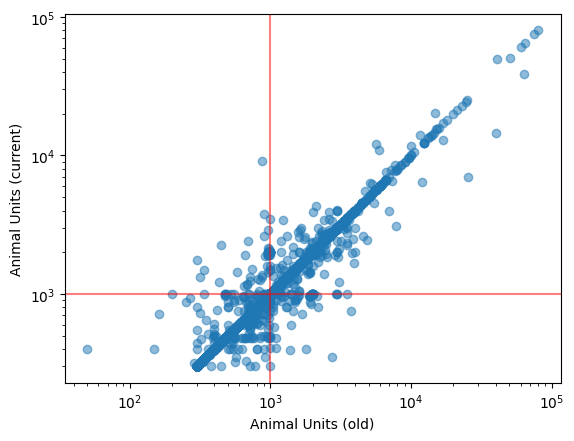

In [70]:
# scatter plot of latitude
plt.axvline(x=1000, color="r", linestyle="-", alpha=0.5)
plt.axhline(y=1000, color="r", linestyle="-", alpha=0.5)
plt.scatter(df_inner["animalunit"], df_inner["animal_units"], alpha=0.5)
plt.xlabel("Animal Units (old)")
plt.ylabel("Animal Units (current)")
plt.xscale("log")
plt.yscale("log")
# add horizontal line at 1000

In [104]:
print(
    f"% Facilities that have exactly the same number of animal units in both datasets: {df_inner[df_inner['animalunit'] == df_inner['animal_units']].shape[0] / df_inner.shape[0] * 100:.2f}%"
)

% Facilities that have exactly the same number of animal units in both datasets: 83.82%


/var/folders/j9/v91rl0vd50v95fh3q9t2jmd80000gn/T/ipykernel_83715/2002401908.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inner_small["1000ormore"] = df_inner_small["animal_units"] >= 1000


Text(0, 0.5, 'Animal Units (current)')

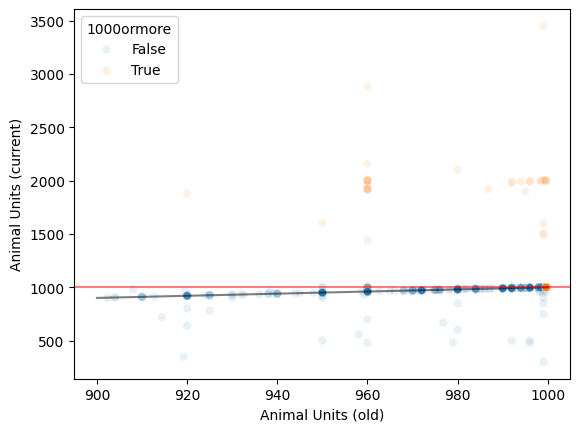

In [109]:
# lets look at only those facilities that had than 1000 animal units in the old dataset
df_inner_small = df_inner[
    (df_inner["animalunit"] < 1000) & (df_inner["animalunit"] > 900)
]
df_inner_small["1000ormore"] = df_inner_small["animal_units"] >= 1000
# scatter plot of animal units, color by 1000ormore
sns.scatterplot(
    data=df_inner_small, x="animalunit", y="animal_units", hue="1000ormore", alpha=0.1
)
# add ab line
plt.plot([900, 1000], [900, 1000], "k-", alpha=0.5)
# add horizontal line at 1000
plt.axhline(y=1000, color="r", linestyle="-", alpha=0.5)
plt.xlabel("Animal Units (old)")
plt.ylabel("Animal Units (current)")

In [102]:
print(
    f" {np.sum(df_inner_small.animal_units==1000)} ({round(np.sum(df_inner_small.animal_units==1000)/df_inner_small.shape[0] * 100, 2)})% of the facilities with less than 1000 animal units in the old dataset have exactly 1000 animal units in the current dataset"
)

 304 (9.83)% of the facilities with less than 1000 animal units in the old dataset have exactly 1000 animal units in the current dataset


In [108]:
print(f" {np.sum(df_inner_small.animalunit==999)} ")

 105 
